# E3 — Feature-signal sweep: does topology stop mattering once features are informative?

Reads `e3_feature_signal_results.json` (written by `run_e3.py`) and
`feature_signal_empirical.json` (written by `run_e3.py`'s Step 0b
diagnostic) and produces `figures/fig5_feature_signal_crossover.png`.
**This notebook only reads results and plots — it never trains a model.**
Re-running it top to bottom should take seconds.

See `README.md` in this folder for the scientific question (H1, H2), the
experimental design, and the finding.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

_HERE = Path.cwd().resolve()
_IS_ANALYSIS_DIR = (
    (_HERE / "e3_feature_signal_results.json").exists()
    or (_HERE / "run_e3.py").exists()
)
_ANALYSIS_DIR = _HERE if _IS_ANALYSIS_DIR else _HERE.parent
_CHALLENGE_DIR = _ANALYSIS_DIR.parent.parent
for _p in (_CHALLENGE_DIR,):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

# Import the challenge `utils.py` (not `topobench.utils`) *before* any
# `topobench` import — see the note in `run_e3.py` for why.
from utils import apply_publication_matplotlib_style

RESULTS_PATH = _ANALYSIS_DIR / "e3_feature_signal_results.json"
FEATURE_SIGNAL_CACHE_PATH = _ANALYSIS_DIR / "feature_signal_empirical.json"
FIGURES_DIR = _ANALYSIS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

apply_publication_matplotlib_style()

In [2]:
with RESULTS_PATH.open(encoding="utf-8") as f:
    all_records = json.load(f)

ok_records = [r for r in all_records if r.get("status") == "ok"]
failed_records = [r for r in all_records if r.get("status") != "ok"]

print(f"{len(all_records)} total record(s): {len(ok_records)} ok, {len(failed_records)} failed.")
if failed_records:
    print("Failed runs:")
    for r in failed_records:
        print(f"  - {r.get('point')}/{r.get('model')}/s{r.get('seed')}: {r.get('error')}")

30 total record(s): 30 ok, 0 failed.


## Design constants

`POINT_ORDER` is the 5-point `center_variance` sweep at the fixed
structural cell `h_mid__d_lo__pl_lo` (see `README.md`). The x axis uses the
empirical `feature_signal` from `feature_signal_empirical.json` (Step 0b)
if present, else falls back to `center_variance` on a log scale.

In [3]:
POINT_ORDER = ["fs_00", "fs_01", "fs_02", "fs_03", "fs_04"]
CENTER_VARIANCE_BY_POINT = {"fs_00": 0.02, "fs_01": 0.05, "fs_02": 0.2, "fs_03": 0.8, "fs_04": 2.0}
OFFICIAL_POINT = "fs_02"

MODEL_ORDER = ["hypergraph/dphgnn", "graph/gcn"]
MODEL_LABELS = {"hypergraph/dphgnn": "DPHGNN", "graph/gcn": "GCN"}
MODEL_COLORS = {"hypergraph/dphgnn": "#1b9e77", "graph/gcn": "#d95f02"}

feature_signal_by_point = {}
feature_signal_available = FEATURE_SIGNAL_CACHE_PATH.exists()
if feature_signal_available:
    with FEATURE_SIGNAL_CACHE_PATH.open(encoding="utf-8") as f:
        _fs_cache = json.load(f)
    for p in POINT_ORDER:
        entry = _fs_cache.get(p, {})
        feature_signal_by_point[p] = entry.get("mean_feature_signal")
    feature_signal_available = all(
        feature_signal_by_point.get(p) is not None for p in POINT_ORDER
    )

if feature_signal_available:
    X_BY_POINT = feature_signal_by_point
    X_LABEL = "Empirical feature signal (RF macro-F1, features only)"
    X_OFFICIAL = X_BY_POINT[OFFICIAL_POINT]
    print("Step 0b succeeded: using empirical feature_signal as the x axis.")
    for p in POINT_ORDER:
        print(f"  {p}: center_variance={CENTER_VARIANCE_BY_POINT[p]:<5} feature_signal={X_BY_POINT[p]:.3f}")
else:
    X_BY_POINT = CENTER_VARIANCE_BY_POINT
    X_LABEL = "center_variance (log scale) — Step 0b diagnostic unavailable"
    X_OFFICIAL = X_BY_POINT[OFFICIAL_POINT]
    print(
        "Step 0b (empirical feature_signal) unavailable or incomplete — "
        "falling back to center_variance on the x axis. See README.md, "
        "Known risks."
    )

seeds_present = sorted({int(r["seed"]) for r in ok_records})
n_seeds = len(seeds_present)
print(f"\nSeeds present: {seeds_present}")
if n_seeds <= 1:
    print(
        "\n*** Phase 1 uses a single seed; differences under ~2 accuracy "
        "points are not interpretable, and no crossover point should be "
        "quoted numerically. ***"
    )

Step 0b succeeded: using empirical feature_signal as the x axis.
  fs_00: center_variance=0.02  feature_signal=0.139
  fs_01: center_variance=0.05  feature_signal=0.142
  fs_02: center_variance=0.2   feature_signal=0.293
  fs_03: center_variance=0.8   feature_signal=0.932
  fs_04: center_variance=2.0   feature_signal=1.000

Seeds present: [42, 43, 44]


In [4]:
def accuracies(point, model):
    """Return the list of test accuracies for (point, model) over available seeds."""
    return [
        r["test_accuracy"]
        for r in ok_records
        if r["point"] == point and r["model"] == model and r["test_accuracy"] is not None
    ]


def mean_accuracy(point, model):
    vals = accuracies(point, model)
    return float(np.mean(vals)) if vals else float("nan")


acc_table = {
    model: [mean_accuracy(p, model) for p in POINT_ORDER] for model in MODEL_ORDER
}
for model in MODEL_ORDER:
    print(MODEL_LABELS[model], [f"{v:.3f}" if np.isfinite(v) else "NA" for v in acc_table[model]])

delta = [
    acc_table["hypergraph/dphgnn"][i] - acc_table["graph/gcn"][i] for i in range(len(POINT_ORDER))
]
print("\nDelta (DPHGNN - GCN):", [f"{d:+.3f}" if np.isfinite(d) else "NA" for d in delta])

DPHGNN ['0.074', '0.096', '0.407', '0.969', '0.999']
GCN ['0.071', '0.099', '0.376', '0.969', '0.999']

Delta (DPHGNN - GCN): ['+0.003', '-0.002', '+0.031', '+0.000', '+0.000']


## Results table

In [5]:
import pandas as pd

rows = []
for p in POINT_ORDER:
    row = {
        "point": p,
        "center_variance": CENTER_VARIANCE_BY_POINT[p],
        "feature_signal_empirical": feature_signal_by_point.get(p) if feature_signal_available else None,
        "dphgnn_acc": acc_table["hypergraph/dphgnn"][POINT_ORDER.index(p)],
        "gcn_acc": acc_table["graph/gcn"][POINT_ORDER.index(p)],
    }
    row["delta"] = row["dphgnn_acc"] - row["gcn_acc"]
    rows.append(row)
results_df = pd.DataFrame(rows)
results_df

,point,center_variance,feature_signal_empirical,dphgnn_acc,gcn_acc,delta
0,fs_00,0.02,0.139415,0.073828,0.070759,0.003069
1,fs_01,0.05,0.142390,0.096200,0.098594,-0.002394
2,fs_02,0.20,0.293442,0.406843,0.376092,0.030751
3,fs_03,0.80,0.932306,0.969185,0.968701,0.000484
4,fs_04,2.00,1.000000,0.999465,0.999402,0.000064


## Figure 5 — feature-signal crossover

Two stacked panels sharing the x axis. Top: accuracy vs. x for DPHGNN and
GCN (plus, if Step 0b succeeded, a dotted grey "features only" reference
line at `y = feature_signal` — any model below that line is being actively
hurt by the graph). Bottom: `Δ = DPHGNN − GCN`, shaded where `Δ > 0`. The
official `center_variance = 0.2` setting is marked with a labelled vertical
line in both panels.

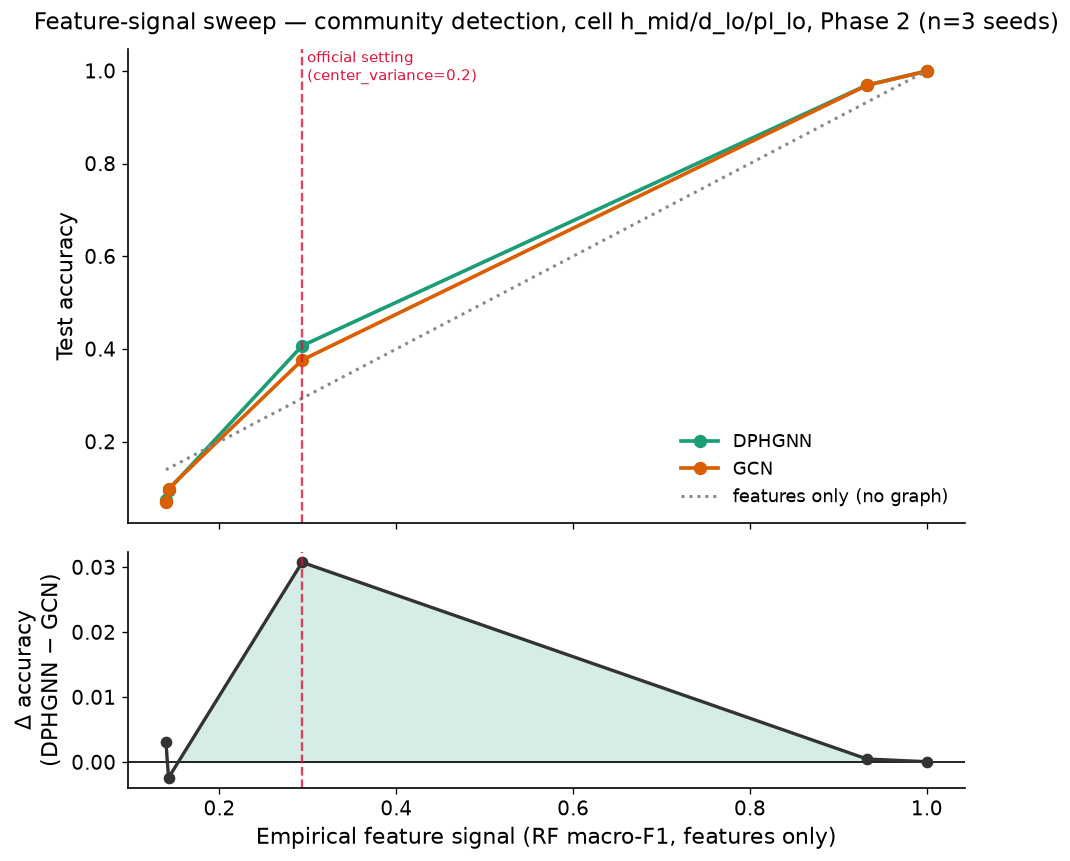

In [6]:
x_vals = np.array([X_BY_POINT[p] for p in POINT_ORDER], dtype=float)
use_log = not feature_signal_available

fig, (ax_top, ax_bot) = plt.subplots(
    nrows=2, ncols=1, figsize=(9, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08},
)

for model in MODEL_ORDER:
    y = np.array(acc_table[model], dtype=float)
    ax_top.plot(
        x_vals, y, marker="o", linewidth=2.2, markersize=7,
        color=MODEL_COLORS[model], label=MODEL_LABELS[model],
    )

if feature_signal_available:
    ax_top.plot(
        x_vals, x_vals, linestyle=":", linewidth=1.8, color="#888888",
        label="features only (no graph)",
    )

if use_log:
    ax_top.set_xscale("log")
ax_top.axvline(X_OFFICIAL, color="crimson", linestyle="--", linewidth=1.4, alpha=0.8)
ax_top.text(
    X_OFFICIAL, ax_top.get_ylim()[1] if ax_top.get_ylim()[1] else 1.0,
    " official setting\n (center_variance=0.2)",
    color="crimson", fontsize=9, va="top", ha="left",
)
ax_top.set_ylabel("Test accuracy")
phase_tag = "Phase 1 (n=1 seed)" if n_seeds <= 1 else f"Phase 2 (n={n_seeds} seeds)"
ax_top.set_title(
    f"Feature-signal sweep — community detection, cell h_mid/d_lo/pl_lo, {phase_tag}",
    pad=12,
)
ax_top.legend(loc="lower right", frameon=False)

delta_arr = np.array(delta, dtype=float)
ax_bot.axhline(0.0, color="black", linewidth=1.0)
ax_bot.plot(x_vals, delta_arr, marker="o", linewidth=2.0, markersize=6, color="#333333")
finite = np.isfinite(delta_arr)
if finite.sum() >= 2:
    ax_bot.fill_between(
        x_vals, 0.0, delta_arr,
        where=(delta_arr > 0) & finite,
        color=MODEL_COLORS["hypergraph/dphgnn"], alpha=0.18, interpolate=True,
    )
ax_bot.axvline(X_OFFICIAL, color="crimson", linestyle="--", linewidth=1.4, alpha=0.8)
ax_bot.set_ylabel("Δ accuracy\n(DPHGNN − GCN)")
ax_bot.set_xlabel(X_LABEL)

fig.savefig(FIGURES_DIR / "fig5_feature_signal_crossover.png", dpi=300, bbox_inches="tight")
plt.show()

## Statistics

**Phase 1 (n=1):** descriptive only — see the caveat printed above. No
crossover point should be quoted numerically.

**Phase 2 (n=3):** bootstrap 95% CI on Δ at each point, reported as an
*interval* where the CI crosses zero (never a single crossover number),
plus Spearman ρ between x and Δ to test monotonicity — the
actual content of H1.

In [7]:
def bootstrap_ci(values, n_boot=2000, ci=0.95, rng=None):
    """Return a (mean, lo, hi) percentile bootstrap CI for `values`."""
    values = np.asarray([v for v in values if np.isfinite(v)], dtype=float)
    if values.size == 0:
        return float("nan"), float("nan"), float("nan")
    rng = rng or np.random.default_rng(0)
    boots = rng.choice(values, size=(n_boot, values.size), replace=True).mean(axis=1)
    lo, hi = np.percentile(boots, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])
    return float(values.mean()), float(lo), float(hi)


def bootstrap_delta_ci(point, n_boot=2000, ci=0.95, rng=None):
    """Bootstrap a CI on Δ = DPHGNN - GCN at one point via paired-seed resampling of each arm's accuracies."""
    a = np.asarray(accuracies(point, "hypergraph/dphgnn"), dtype=float)
    b = np.asarray(accuracies(point, "graph/gcn"), dtype=float)
    if a.size == 0 or b.size == 0:
        return float("nan"), float("nan"), float("nan")
    rng = rng or np.random.default_rng(0)
    boots_a = rng.choice(a, size=(n_boot, a.size), replace=True).mean(axis=1)
    boots_b = rng.choice(b, size=(n_boot, b.size), replace=True).mean(axis=1)
    boots_delta = boots_a - boots_b
    lo, hi = np.percentile(boots_delta, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])
    return float(a.mean() - b.mean()), float(lo), float(hi)


if n_seeds < 3:
    print(
        "Single seed; differences under ~2 accuracy points are not "
        "interpretable, and no crossover point should be quoted "
        "numerically."
    )
    print("\nRaw Δ per point (descriptive only):")
    for p, d in zip(POINT_ORDER, delta, strict=True):
        marker = "  <-- official" if p == OFFICIAL_POINT else ""
        print(f"  {p}: x={X_BY_POINT[p]:.3f}  Δ={d:+.3f}{marker}")
else:
    print("Bootstrap 95% CI on Δ = DPHGNN - GCN, per point:")
    ci_crosses_zero = []
    for p in POINT_ORDER:
        mean_d, lo, hi = bootstrap_delta_ci(p)
        crosses = lo <= 0.0 <= hi
        ci_crosses_zero.append(crosses)
        marker = "  <-- official" if p == OFFICIAL_POINT else ""
        print(f"  {p}: x={X_BY_POINT[p]:.3f}  Δ={mean_d:+.3f}  95% CI=[{lo:+.3f}, {hi:+.3f}]{marker}")

    crossover_points = [X_BY_POINT[p] for p, c in zip(POINT_ORDER, ci_crosses_zero, strict=True) if c]
    if crossover_points:
        print(
            f"\nCrossover interval (CI on Δ contains zero): "
            f"[{min(crossover_points):.3f}, {max(crossover_points):.3f}] on the x axis. "
            "Reported as an interval, not a point estimate — 5 points / 3 "
            "seeds cannot localise it more precisely."
        )
    else:
        print("\nNo point has a CI on Δ containing zero (sign of Δ is consistent across the sweep).")

    rho, pval = stats.spearmanr(x_vals, delta_arr)
    print(f"\nSpearman rho(x, Δ) = {rho:.3f} (p={pval:.3g}) — tests monotonicity (H1's actual content).")

Bootstrap 95% CI on Δ = DPHGNN - GCN, per point:
  fs_00: x=0.139  Δ=+0.003  95% CI=[+0.001, +0.005]
  fs_01: x=0.142  Δ=-0.002  95% CI=[-0.008, +0.004]
  fs_02: x=0.293  Δ=+0.031  95% CI=[+0.027, +0.035]  <-- official
  fs_03: x=0.932  Δ=+0.000  95% CI=[-0.001, +0.002]
  fs_04: x=1.000  Δ=+0.000  95% CI=[-0.000, +0.000]

Crossover interval (CI on Δ contains zero): [0.142, 1.000] on the x axis. Reported as an interval, not a point estimate — 5 points / 3 seeds cannot localise it more precisely.

Spearman rho(x, Δ) = -0.200 (p=0.747) — tests monotonicity (H1's actual content).


## Where does the official setting sit?

`center_variance = 0.2` (`fs_02`) is the official challenge value. Its
position on the curve above — left of, at, or right of any crossover —
is the headline finding for H2. See `README.md`, Finding.